In [14]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

In [15]:
# Load the dataset
df = pd.read_csv('petProfiles.csv')

print("Initial DataFrame Head:")
print(df.head())

print("\nInitial DataFrame Info:")
print(df.info())

# Identify categorical columns and one-hot encode them
categorical_cols = []
if 'pet_breed' in df.columns:
    categorical_cols.append('pet_breed')
if 'size' in df.columns:
    categorical_cols.append('size')
if 'gender' in df.columns:
    categorical_cols.append('gender')

if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols)

# Fill missing numeric columns if needed
if 'age' in df.columns:
    df['age'].fillna(df['age'].mean(), inplace=True)
if 'latitude' in df.columns:
    df['latitude'].fillna(df['latitude'].mean(), inplace=True)
if 'longitude' in df.columns:
    df['longitude'].fillna(df['longitude'].mean(), inplace=True)

# Cast everything to float32 for TensorFlow compatibility
df = df.astype('float32')

print("\nAfter Encoding & Casting, DataFrame Info:")
print(df.info())

# Split into train and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train set size: {len(train_df)}")
print(f"Test set size:  {len(test_df)}")


Initial DataFrame Head:
   username       pet_breed  age    size  gender   latitude  longitude
0      4860          Beagle    5   small  Female  27.300590  33.071099
1      7863           Boxer    3  medium  Female  27.542401  30.838131
2      6431  Siberian Husky    3  medium    Male  25.676053  34.791213
3      8600       Dachshund   13   small    Male  29.859260  35.052661
4      8861         Maltese    2   small    Male  22.637550  28.891340

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   5000 non-null   int64  
 1   pet_breed  5000 non-null   object 
 2   age        5000 non-null   int64  
 3   size       5000 non-null   object 
 4   gender     5000 non-null   object 
 5   latitude   5000 non-null   float64
 6   longitude  5000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 273.6

In [16]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Compute the Haversine distance in kilometers between two points specified in degrees.
    """
    R = 6371.0  # Earth radius in km
    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)
    a = (math.sin(d_lat / 2)**2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(d_lon / 2)**2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def create_pairs_sampled(df_subset, num_samples=10000, age_threshold=4.0, distance_threshold=50.0):
    """
    Randomly sample pairs from df_subset and label them according to:
      - Opposite gender
      - Haversine distance <= distance_threshold km
      - Age difference <= age_threshold
      - (Same breed OR same size)
    This sampling strategy avoids the combinatorial explosion when using all pairs.
    """
    data = df_subset.values  # shape: (num_rows, num_features)
    columns = list(df_subset.columns)
    
    # Identify one-hot encoded columns for breed, size, gender
    breed_cols  = [c for c in columns if c.startswith('pet_breed_')]
    size_cols   = [c for c in columns if c.startswith('size_')]
    gender_cols = [c for c in columns if c.startswith('gender_')]
    
    lat_idx = columns.index('latitude')
    lon_idx = columns.index('longitude')
    age_idx = columns.index('age')
    
    breed_indices  = [columns.index(c) for c in breed_cols]
    size_indices   = [columns.index(c) for c in size_cols]
    gender_indices = [columns.index(c) for c in gender_cols]

    def opposite_gender(vecA, vecB):
        try:
            idx_male   = [i for i, c in enumerate(gender_cols) if 'Male' in c][0]
            idx_female = [i for i, c in enumerate(gender_cols) if 'Female' in c][0]
        except IndexError:
            return False
        male_idx   = gender_indices[idx_male]
        female_idx = gender_indices[idx_female]
        A_is_male = (vecA[male_idx] > 0.5)
        A_is_fem  = (vecA[female_idx] > 0.5)
        B_is_male = (vecB[male_idx] > 0.5)
        B_is_fem  = (vecB[female_idx] > 0.5)
        return (A_is_male and B_is_fem) or (A_is_fem and B_is_male)

    def within_distance(vecA, vecB, km_thresh):
        lat1, lon1 = vecA[lat_idx], vecA[lon_idx]
        lat2, lon2 = vecB[lat_idx], vecB[lon_idx]
        return haversine_distance(lat1, lon1, lat2, lon2) <= km_thresh

    def age_in_range(vecA, vecB, max_diff):
        return abs(vecA[age_idx] - vecB[age_idx]) <= max_diff

    pairs_list = []
    labels_list = []
    n = data.shape[0]
    
    for _ in range(num_samples):
        i = np.random.randint(0, n)
        j = np.random.randint(0, n)
        while j == i:
            j = np.random.randint(0, n)
        petA = data[i]
        petB = data[j]
        label = 0.0

        if (opposite_gender(petA, petB) and 
            within_distance(petA, petB, distance_threshold) and 
            age_in_range(petA, petB, age_threshold)):
            
            same_breed = any((petA[idx] > 0.5 and petB[idx] > 0.5) for idx in breed_indices)
            same_size  = any((petA[idx] > 0.5 and petB[idx] > 0.5) for idx in size_indices)
            if same_breed or same_size:
                label = 1.0
        
        pairs_list.append([petA, petB])
        labels_list.append(label)
        
    pairs_array  = np.array(pairs_list,  dtype='float32')
    labels_array = np.array(labels_list, dtype='float32')
    return pairs_array, labels_array

# Generate sampled pairs for training and testing
pairs_train, labels_train = create_pairs_sampled(train_df, num_samples=10000, age_threshold=4.0, distance_threshold=50.0)
pairs_test,  labels_test  = create_pairs_sampled(test_df, num_samples=2000,  age_threshold=4.0, distance_threshold=50.0)

print(f"Train pairs: {pairs_train.shape},  Train labels: {labels_train.shape}")
print(f"Test pairs:  {pairs_test.shape},   Test labels: {labels_test.shape}")

# Separate pairs into features for pet A and pet B
pet_features_1_train = pairs_train[:, 0]
pet_features_2_train = pairs_train[:, 1]
pet_features_1_test  = pairs_test[:, 0]
pet_features_2_test  = pairs_test[:, 1]


Train pairs: (10000, 2, 29),  Train labels: (10000,)
Test pairs:  (2000, 2, 29),   Test labels: (2000,)


In [17]:
def create_subnetwork(input_shape):
    inp = Input(shape=input_shape)
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)  # final embedding dimension
    return models.Model(inp, x)

input_shape = (pet_features_1_train.shape[1],)
pet_network = create_subnetwork(input_shape)

# Build Siamese model using the same subnetwork for both inputs
input_pet1 = Input(shape=input_shape, name='pet1_input')
input_pet2 = Input(shape=input_shape, name='pet2_input')

embedding_pet1 = pet_network(input_pet1)
embedding_pet2 = pet_network(input_pet2)

def euclidean_distance(vectors):
    petA, petB = vectors
    return tf.sqrt(tf.reduce_sum(tf.square(petA - petB), axis=1, keepdims=True))

distance = layers.Lambda(euclidean_distance, name='distance')([embedding_pet1, embedding_pet2])
model = models.Model(inputs=[input_pet1, input_pet2], outputs=distance)
model.summary()


Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 pet1_input (InputLayer)        [(None, 29)]         0           []                               
                                                                                                  
 pet2_input (InputLayer)        [(None, 29)]         0           []                               
                                                                                                  
 model_4 (Functional)           (None, 16)           4912        ['pet1_input[0][0]',             
                                                                  'pet2_input[0][0]']             
                                                                                                  
 distance (Lambda)              (None, 1)            0           ['model_4[0][0]',          

In [18]:
def contrastive_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    margin = 1.0
    y_pred = tf.abs(y_pred)
    loss = y_true * tf.square(y_pred) + (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0.0))
    return tf.reduce_mean(loss)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=contrastive_loss)

# Create tf.data datasets for efficient training
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_train, pet_features_2_train), labels_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_test, pet_features_2_test), labels_test))
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Add callbacks for early stopping, learning rate reduction, and TensorBoard monitoring
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    tf.keras.callbacks.TensorBoard(log_dir='./logs')
]


Epoch 1/50
313/313 [==============================] - 6s 13ms/step - loss: 0.0059 - val_loss: 0.0744 - lr: 1.0000e-04
Epoch 2/50
313/313 [==============================] - 4s 12ms/step - loss: 0.0060 - val_loss: 0.0752 - lr: 1.0000e-04
Epoch 3/50
313/313 [==============================] - 4s 12ms/step - loss: 0.0074 - val_loss: 0.0754 - lr: 1.0000e-04
Epoch 4/50
313/313 [==============================] - 3s 9ms/step - loss: 0.0088 - val_loss: 0.0742 - lr: 1.0000e-04
Epoch 5/50
313/313 [==============================] - 3s 9ms/step - loss: 0.0080 - val_loss: 0.0738 - lr: 1.0000e-04
Epoch 6/50
313/313 [==============================] - 3s 9ms/step - loss: 0.0074 - val_loss: 0.0776 - lr: 1.0000e-04
Epoch 7/50
313/313 [==============================] - 3s 9ms/step - loss: 0.0080 - val_loss: 0.0643 - lr: 1.0000e-04
Epoch 8/50
313/313 [==============================] - 3s 9ms/step - loss: 0.0099 - val_loss: 0.0747 - lr: 1.0000e-04
Epoch 9/50
313/313 [==============================] - 3s 9ms/

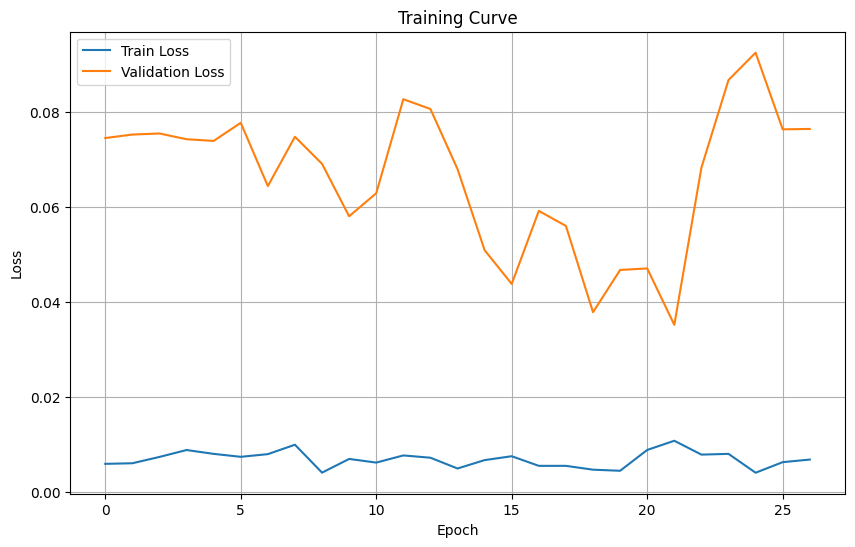

63/63 [==============================] - 0s 4ms/step - loss: 0.0351

Test Loss: 0.03513879328966141


In [19]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=callbacks
)

# Improved visualization of training curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()

test_loss = model.evaluate(test_dataset)
print("\nTest Loss:", test_loss)


In [20]:
import tensorflow as tf

# List all available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs are available:", gpus)
else:
    print("No GPUs detected.")

# Alternatively, print the name of the GPU device
print("TensorFlow GPU device:", tf.test.gpu_device_name())

tf.debugging.set_log_device_placement(True)
# Create some sample tensors and perform an operation to see the device assignment
a = tf.constant([[1.0, 2.0, 3.0]])
b = tf.constant([[4.0, 5.0, 6.0]])
c = a + b
print(c)


GPUs are available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow GPU device: /device:GPU:0
tf.Tensor([[5. 7. 9.]], shape=(1, 3), dtype=float32)
